# Daily Challenge: Classification with Neural Networks in TensorFlow


# 👩‍🏫 👩🏿‍🏫 What You’ll learn
Understand the different types of classification: Binary, Multi-class, and Multi-label
Learn how to build a Neural Network for Classification using TensorFlow
Improve model performance by adding layers, neurons, and using activation functions
Visualize decision boundaries to understand model predictions


# 🛠️ What you will create
A Neural Network model for classification using TensorFlow
Visualizations of data distribution and decision boundaries
Model performance evaluation on training and test sets
Experimentation with activation functions and optimizers


# 📖 Useful Resources
multiclass-classification-vs-multi-label-classification
getting-started-with-classification


# What You Need to Do
# 1. Understand Classification Types

Read about Binary Classification, Multi-class Classification, and Multi-label Classification.
Write a brief explanation of each type with an example.

### Binary Classification

Binary classification is a machine learning task where each sample belongs to one of two possible classes. The model predicts either class 0 or class 1. A common example is spam email detection, where an email is classified as either spam or not spam.

### Multi-class Classification

Multi-class classification is used when each sample belongs to one of more than two classes, but only one class can be correct. An example is handwritten digit recognition, where an image is classified as one of the digits from 0 to 9.

### Multi-label Classification

Multi-label classification allows each sample to belong to multiple classes at the same time. For example, a photo can contain both a dog and a bicycle, so both labels are assigned simultaneously.

# 2. Set Up Your Python Environment and dataset

Ensure you have the required libraries installed.
Visualize the dataset using scatter plots to understand the data distribution.


3. Build a Basic Neural Network Model

Create a Sequential Model in TensorFlow with one dense layer.
Use Binary Crossentropy as the loss function.
Train the model and check the accuracy.


4. Improve the Model

Add more layers and neurons to the model.
Train the model for more epochs.
Try different optimizers like Adam instead of SGD.


5. Visualize the Decision Boundary

Implement a function plot_decision_boundary() to visualize model predictions.
Plot decision boundaries for different models and compare results.


6. Incorporate Activation Functions

Explore ReLU and Sigmoid activation functions.
Modify the neural network to include these activation functions.
Train the new model and compare performance.


7. Split Data into Training and Testing Sets

Use 80% data for training and 20% for testing.
Train the improved model on the training set.
Evaluate model performance on the test set.


8. Evaluate and Visualize Final Model Performance

Check loss and accuracy on the test set.
Use plot_decision_boundary() to visualize predictions for both training and test data.
Compare results and analyze improvements.


9. Summarize Key Takeaways

Write a short summary of what you learned.
Highlight the importance of visualizing data and tuning hyperparameters to improve classification models.




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles


# It is time for creating a dataset to work on:

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Display TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Pipeline

Dataset
      ↓
Visualization (EDA)
      ↓
Train / Test Split
      ↓
Neural Network
      ↓
Training
      ↓
Evaluation
      ↓
Improve the Model
      ↓
Decision Boundary
      ↓
Conclusion

In [2]:
# Generate a synthetic dataset
samples = 1000 # Number of samples (in this case - points)

X, y = make_circles(
    n_samples=samples, #number of observations
    noise=0.03,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X values:")
print(X[:5])

print("\nFirst 5 y values:")
print(y[:5])

X shape: (1000, 2)
y shape: (1000,)

First 5 X values:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y values:
[1 1 1 1 0]


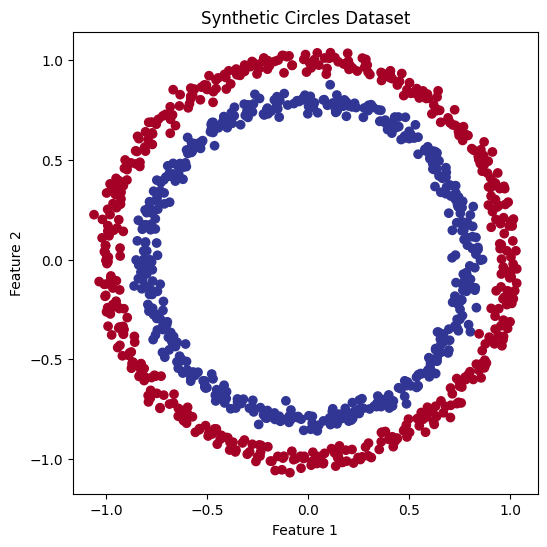

In [3]:
# Visualize the dataset
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0], #all x coordinates
    X[:, 1], #all y coordinates
    c=y, #color according to the class
    cmap=plt.cm.RdYlBu
)

plt.title("Synthetic Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 2)
X_test shape: (200, 2)
y_train shape: (800,)
y_test shape: (200,)


In [5]:
# Build a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

In [6]:
# Configure the model for training
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

In [7]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=1 # data quantity in console (verbose = 0 means to show nothing, verbose = 1 - to show progress, verbose = 2 - show short info without progress)
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4600 - loss: 2.9602
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.7651
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.7196
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.7048
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5050 - loss: 0.6985
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5038 - loss: 0.6957
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5175 - loss: 0.6947
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4888 - loss: 0.6945
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5075 - loss: 0.6939
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5375 - loss: 0.6939
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4675 - loss: 0.6937
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 1)                │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [9]:
# Build an improved neural network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the improved model
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

In [12]:
# Train the improved model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=1
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5025 - loss: 0.6876
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5088 - loss: 0.6857
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6842
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6830
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5113 - loss: 0.6817
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5125 - loss: 0.6804
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5163 - loss: 0.6791
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5150 - loss: 0.6776
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5213 - loss: 0.6760
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5225 - loss: 0.6739
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5288 - loss: 0.6717
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [13]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 1.0000 - loss: 0.0711
Test loss: 0.0711
Test accuracy: 1.0000


In [14]:
# Create a grid of points over the feature space.
# Predict the class for each grid point.
# Color the regions based on the predictions.
# This visualizes the model's decision boundary.
def plot_decision_boundary(model, X, y):
    """
    Plot the decision boundary of a classification model.
    """

    # Define plot boundaries
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    # Create a grid of evenly spaced points
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200), # creates 200 points starting fromx_min ending with x_max, spreading them evenly
        np.linspace(y_min, y_max, 200)
    )

    # Flatten the coordinate grids and combine them into (x, y) pairs.
    # Each row represents one point in the feature space.
    grid = np.c_[xx.ravel(), yy.ravel()] #np.c_ - column-wise concatenate

    # Predict the probability of each point belonging to class 1. Model will take 200*200  = 40 000 points
    y_pred = model.predict(grid, verbose=0)

    # Convert probabilities (true, false) to binary class labels (0 or 1).
    y_pred = (y_pred > 0.5).astype(int)

    # Reshape predictions back to the original grid shape
    # so they can be visualized as a 2D decision boundary.
    y_pred = y_pred.reshape(xx.shape)

    # Create a new figure
    plt.figure(figsize=(6, 6))

    # Draw the decision regions
    plt.contourf(
        xx,
        yy,
        y_pred,
        alpha=0.3,#transparency
        cmap=plt.cm.RdYlBu #colormap
    )

    # Plot the original data points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.RdYlBu,
        edgecolors="black"
    )

    # Add labels and title
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")

    plt.show()

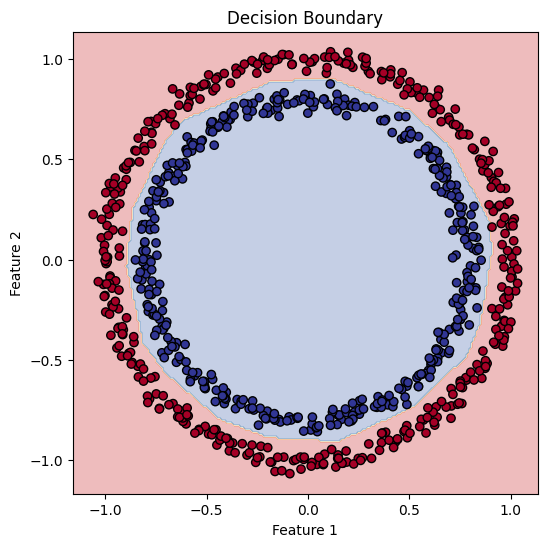

In [15]:
plot_decision_boundary(model, X_train, y_train)

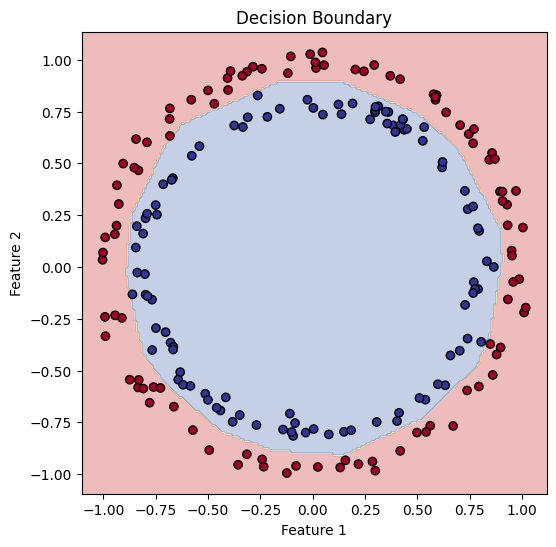

In [16]:
plot_decision_boundary(model, X_test, y_test)

In this exercise, I learned the differences between binary, multi-class, and multi-label classification. I built a neural network in TensorFlow and improved its performance by adding hidden layers, ReLU activation functions, and the Adam optimizer. Visualizing the dataset and the decision boundary helped me understand how the model separates different classes. I also learned that evaluating the model on both training and test data is important to ensure good generalization and avoid overfitting.